Saving modulations(in).csv to modulations(in) (2).csv


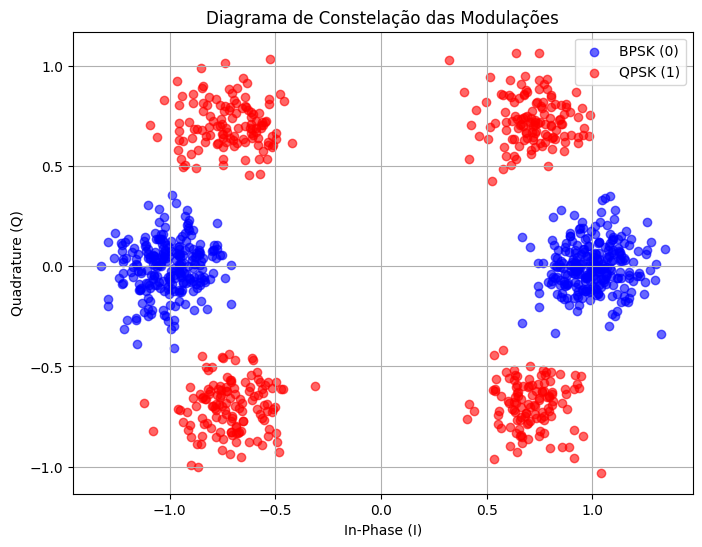


Melhor taxa de aprendizado encontrada: 0.9

Treinando o modelo com 30000 épocas...
Treinamento concluído!


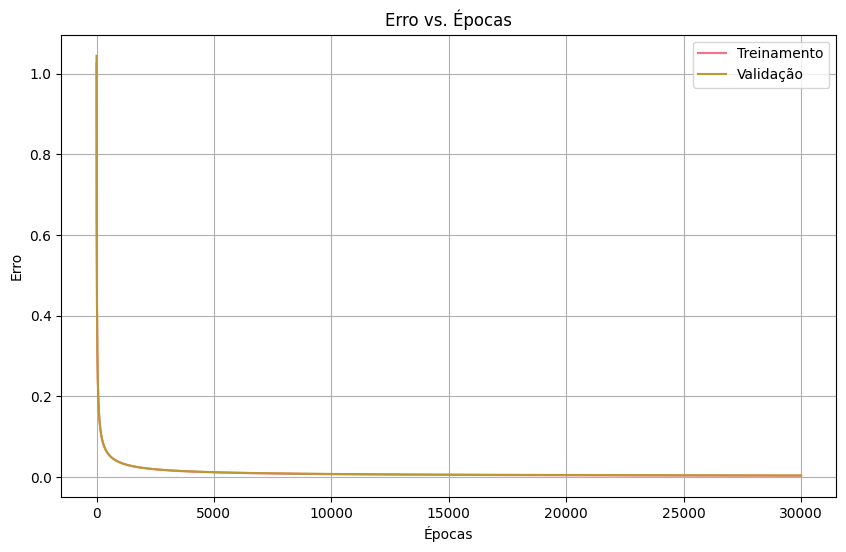


Acurácia do modelo: 1.0000


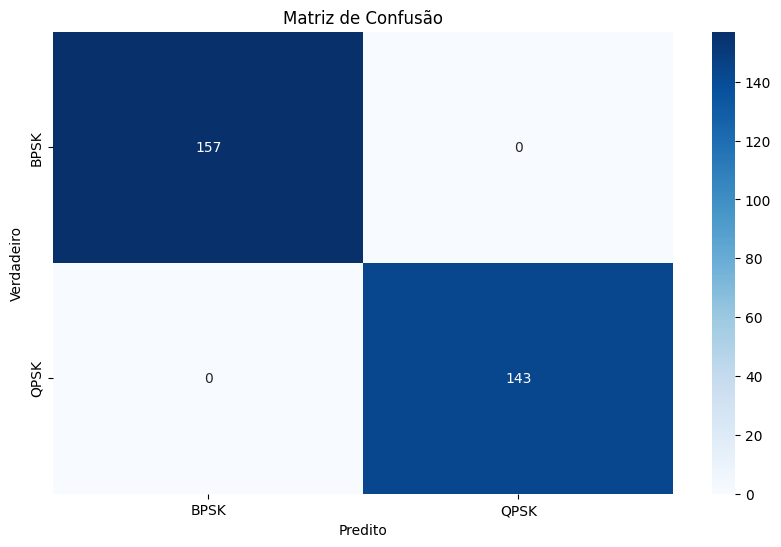

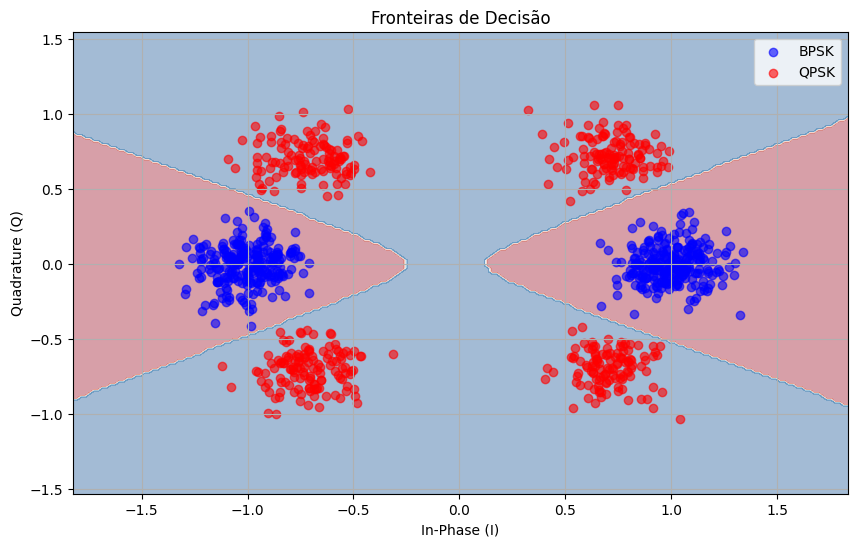

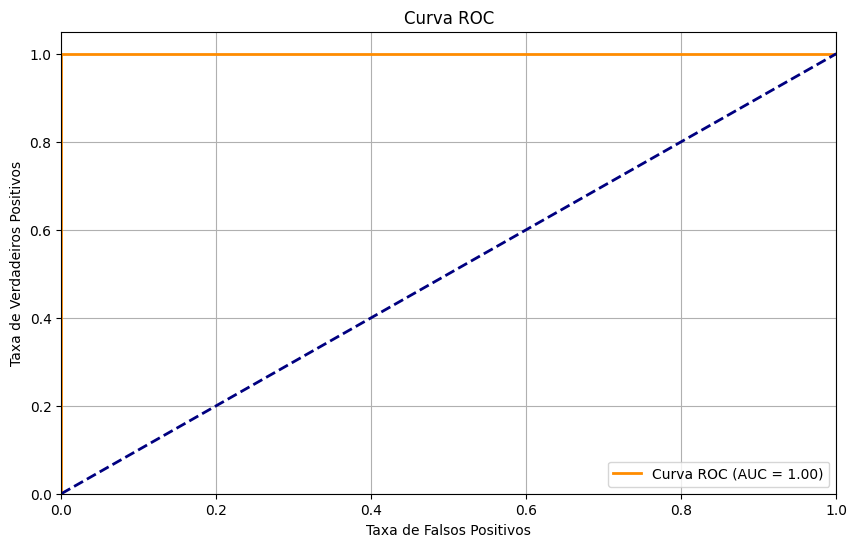


Relatório de Classificação:
              precision    recall  f1-score   support

        BPSK       1.00      1.00      1.00       157
        QPSK       1.00      1.00      1.00       143

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.special import expit
from sklearn.metrics import (accuracy_score, confusion_matrix,
                            classification_report, roc_curve, auc)
import seaborn as sns

# Configuração para melhor visualização
plt.style.use('default')  # Alterado de 'seaborn' para 'default'
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_palette("husl")

class LogisticRegressor:
    '''Implementação do Regressor Logístico com Gradiente Descendente'''

    def __init__(self, alpha=0.1, n_iterations=10000, seed=42):
        self.alpha = alpha
        self.n_iterations = n_iterations
        self.seed = seed

    def sigmoid(self, z):
        return expit(z)

    def predict_proba(self, X, a):
        return self.sigmoid(X.dot(a))

    def predict(self, X, a, threshold=0.5):
        return (self.predict_proba(X, a) >= threshold).astype(int)

    def error_function(self, X, y, a):
        h = self.predict_proba(X, a)
        return -np.mean(y * np.log(h) + (1 - y) * np.log(1 - h))

    def fit(self, X_train, y_train, X_val, y_val):
        np.random.seed(self.seed)
        m, n = X_train.shape
        self.a = np.random.randn(n, 1)

        self.J_train = []
        self.J_val = []
        self.a_min = self.a.copy()
        min_val_error = float('inf')

        for iteration in range(self.n_iterations):
            gradients = X_train.T.dot(self.predict_proba(X_train, self.a) - y_train) / m
            self.a -= self.alpha * gradients

            train_error = self.error_function(X_train, y_train, self.a)
            val_error = self.error_function(X_val, y_val, self.a)

            self.J_train.append(train_error)
            self.J_val.append(val_error)

            if val_error < min_val_error:
                min_val_error = val_error
                self.a_min = self.a.copy()

        return self

def readCSVFile(filename):
    '''Função para ler o arquivo CSV com os dados'''
    df = pd.read_csv(filename, header=None)
    i = df[0].to_numpy()
    q = df[1].to_numpy()
    mod = df[2].to_numpy()
    i = i.reshape(len(i), 1)
    q = q.reshape(len(q), 1)
    mod = mod.reshape(len(mod),)
    return i, q, mod

# Carregar os dados (você precisará fazer upload do arquivo modulations.csv primeiro)
from google.colab import files
uploaded = files.upload()

filename = 'modulations(in).csv'  # Assumindo que o arquivo tem este nome
I, Q, mod = readCSVFile(filename)
y = I + 1j*Q

# a. Plotar gráfico das amostras I e Q por modulação
plt.figure(figsize=(8, 6))
plt.scatter(I[mod==0], Q[mod==0], c='blue', label='BPSK (0)', alpha=0.6)
plt.scatter(I[mod==1], Q[mod==1], c='red', label='QPSK (1)', alpha=0.6)
plt.xlabel('In-Phase (I)')
plt.ylabel('Quadrature (Q)')
plt.title('Diagrama de Constelação das Modulações')
plt.legend()
plt.grid(True)
plt.show()


# Pré-processamento dos dados
# Adicionar features não-lineares (termos quadráticos e produto I*Q para capturar fronteira circular)
X = np.c_[I, Q, I**2, Q**2, I*Q]
X = np.c_[np.ones((X.shape[0], 1)), X]  # Adicionar bias term

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, mod, test_size=0.3, random_state=42)

# Reshape para garantir dimensões corretas
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# c. Treinar o regressor logístico com early stopping
# Encontrar melhor taxa de aprendizado
learning_rates = [0.001, 0.01, 0.1, 0.3, 0.5, 0.9]
best_alpha = None
best_error = float('inf')

for alpha in learning_rates:
    model = LogisticRegressor(alpha=alpha, n_iterations=1000)
    model.fit(X_train, y_train, X_test, y_test)
    val_error = model.J_val[-1]

    if val_error < best_error:
        best_error = val_error
        best_alpha = alpha

print(f"\nMelhor taxa de aprendizado encontrada: {best_alpha}")

# Treinar com o melhor alpha e 30000 épocas
print("\nTreinando o modelo com 30000 épocas...")
model = LogisticRegressor(alpha=best_alpha, n_iterations=30000)
model.fit(X_train, y_train, X_test, y_test)
print("Treinamento concluído!")

# d. Plotar erros de treinamento e validação
plt.figure()
plt.plot(model.J_train, label='Treinamento')
plt.plot(model.J_val, label='Validação')
plt.xlabel('Épocas')
plt.ylabel('Erro')
plt.title('Erro vs. Épocas')
plt.legend()
plt.grid()
plt.show()

# e. Calcular e imprimir acurácia
y_pred = model.predict(X_test, model.a_min)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia do modelo: {accuracy:.4f}")

# f. Plotar matriz de confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['BPSK', 'QPSK'],
            yticklabels=['BPSK', 'QPSK'])
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()

# g. Plotar fronteiras de decisão
# Criar grid para plotar as fronteiras
h = 0.02  # tamanho do passo no grid
i_min, i_max = I.min() - 0.5, I.max() + 0.5
q_min, q_max = Q.min() - 0.5, Q.max() + 0.5
ii, qq = np.meshgrid(np.arange(i_min, i_max, h), np.arange(q_min, q_max, h))

# Calcular predições para cada ponto do grid
grid_X = np.c_[np.ones((len(ii.ravel()), 1)),
               ii.ravel().reshape(-1,1),
               qq.ravel().reshape(-1,1),
               ii.ravel().reshape(-1,1)**2,
               qq.ravel().reshape(-1,1)**2,
               ii.ravel().reshape(-1,1)*qq.ravel().reshape(-1,1)]
Z = model.predict(grid_X, model.a_min)
Z = Z.reshape(ii.shape)

# Plotar
plt.figure()
plt.contourf(ii, qq, Z, alpha=0.4, cmap='RdBu')
plt.scatter(I[mod==0], Q[mod==0], c='blue', label='BPSK', alpha=0.6)
plt.scatter(I[mod==1], Q[mod==1], c='red', label='QPSK', alpha=0.6)
plt.xlabel('In-Phase (I)')
plt.ylabel('Quadrature (Q)')
plt.title('Fronteiras de Decisão')
plt.legend()
plt.grid()
plt.show()

# h. Plotar curva ROC
y_scores = model.predict_proba(X_test, model.a_min)
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.grid()
plt.show()

# i. Imprimir métricas de classificação
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['BPSK', 'QPSK']))